# Drift Detection in Multiclass Imbalanced Datastreams

Objectives:
- Evaluate and compare the effectiveness of different concept drift detection methods on multi-class imbalanced data streams
- Evaluate how class imbalance affects the performance of drift detectors
- Evaluate how different drift types (abrupt vs. gradual) impact detector performance

Each experiment follows the prequential protocol:
1. Predict
2. Run drift detector
3. Update metrics
4. Learn

In [ ]:
from river import tree, metrics
from river.datasets import synth
from river.drift import ADWIN, KSWIN
from river.drift.binary import DDM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools
from collections import deque
from sklearn.decomposition import IncrementalPCA

import torch
import torch.nn as nn
import torch.nn.functional as F

## Metric Tracker

In [ ]:
class MetricsTracker:
    def __init__(self):
        self.en_accuracy = metrics.Accuracy()
        self.g_mean = metrics.GeometricMean()
        self.current_step = 0

        self.injected_drifts = [] 
        self.detected_drift_ids = set() 
        self.false_alarms = 0
        self.all_delays = []
        self.acc_history = []
        self.gmean_history = []
        

    def update(self, y_true, y_pred, drift_detected=False, gt_drifts=None):
        # Accuracy and G-Mean
        if y_pred is not None:
            self.en_accuracy.update(y_true, y_pred)
            self.g_mean.update(y_true, y_pred)

        # Delay и False Alarms
        if gt_drifts is not None and len(self.injected_drifts) == 0:
            self.injected_drifts = gt_drifts

        self.acc_history.append(self.en_accuracy.get())
        self.gmean_history.append(self.g_mean.get())

        # Drift Detections
        if drift_detected:
            closest_idx = None
            closest_dist = float("inf")
            for i, drift_step in enumerate(self.injected_drifts):
                if i in self.detected_drift_ids:
                    continue
                dist = self.current_step - drift_step
                # allow only forward matching (after drift happens)
                if dist >= 0 and dist < closest_dist:
                    closest_dist = dist
                    closest_idx = i
            # valid detection
            if closest_idx is not None: 
                self.detected_drift_ids.add(closest_idx)
                delay = closest_dist
                self.all_delays.append(delay)
            # False Alarms
            else:
                self.false_alarms += 1

        self.current_step += 1

    def get_metrics(self):
        avg_delay = np.mean(self.all_delays) if self.all_delays else 0
        n_injected = len(self.injected_drifts)

        tp = len(self.detected_drift_ids)
        fp = self.false_alarms
        recall = tp / n_injected if n_injected > 0 else 0.0
        
        total_alerts = tp + fp
        far = fp / total_alerts if total_alerts > 0 else 0.0
        
        # Precision 1 - FAR
        precision = tp / total_alerts if total_alerts > 0 else 0.0
        
        # HDD (Harmonic mean of precision and recall)
        hdd = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0.0
   
        return {
            "Accuracy": self.en_accuracy.get(),
            "G-Mean": self.g_mean.get(),
            "Delay": avg_delay,
            "Recall": recall,
            "Precision": precision,
            "FAR": far,
            "HDD":hdd
        }

## Drift Detectors

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, x_dim, p_dim, hidden_dim=16, latent_dim=8):
        super().__init__()

        self.x_dim = x_dim
        self.p_dim = p_dim
        self.input_dim = x_dim + p_dim

        # Shared encoder
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # Feature decoder
        self.decoder_x = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, x_dim)
        )

        # Probability decoder
        self.decoder_p = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, p_dim),
            nn.Softmax(dim=1) 
        )

    def forward(self, x, p):
        z = torch.cat([x, p], dim=1)
        h = self.encoder(z)

        x_hat = self.decoder_x(h)
        p_hat = self.decoder_p(h)

        return x_hat, p_hat
    
class DHAE: # Dual Head AutoEncoder
    def __init__(
        self,
        n_features,
        n_classes,
        hidden_dim=16,
        latent_dim=8,
        lr=1e-3,
        lambda_x=0.5,
        lambda_p=5, 
        adwin_delta=0.002
    ):
        self.model = Autoencoder(n_features, n_classes, hidden_dim, latent_dim)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.lambda_x = lambda_x
        self.lambda_p = lambda_p

        self.adwin = ADWIN(delta=adwin_delta)

        self.cooldown = 200
        self.cooldown_counter = 0

        self.n_classes=n_classes

        self.score_history=deque(maxlen=200)
        self.step=0
        
    def _compute_loss(self, x, x_hat, p, p_hat):
        loss_x = F.mse_loss(x_hat, x)
        loss_p = F.mse_loss(p_hat, p)
        total_loss = self.lambda_x * loss_x + self.lambda_p * loss_p

        return total_loss 

    def update(self, x, probas,**kwargs):
        self.step+=1
        if not probas:
            probas = {c: 1.0 / self.n_classes for c in range(self.n_classes)}
        p_list = [probas.get(c, 1e-3) for c in range(self.n_classes)]
        if sum(p_list) == 0:
            p_list = [1.0 / self.n_classes] * self.n_classes

        x_tensor = torch.FloatTensor(list(x.values())).unsqueeze(0)
        p_tensor = torch.FloatTensor(p_list).unsqueeze(0)

        if self.cooldown_counter > 0:
            self.cooldown_counter -= 1
            return False 
        
        self.model.eval()
        with torch.no_grad():
            x_hat, p_hat = self.model(x_tensor, p_tensor)

            total_loss= self._compute_loss(x_tensor, x_hat, p_tensor, p_hat)

        score = total_loss.item()

        # Drift detection 
        self.adwin.update(score)
        
        if self.adwin.drift_detected:
            self.cooldown_counter = self.cooldown
            print("drift detected at step: ",self.step, "score= ",score)
            self.adwin = ADWIN(delta=self.adwin.delta) #new
            return True 

        # Training only when stable
        self.score_history.append(score)
        if len(self.score_history) > 200:
            if score < np.percentile(self.score_history, 99): #90
                self._train_step(x_tensor, p_tensor)

        return False

    def _train_step(self, x, p):
        self.model.train()
        self.optimizer.zero_grad()
        x_hat, p_hat = self.model(x, p)
        total_loss = self._compute_loss(x, x_hat, p, p_hat)
        total_loss.backward()
        self.optimizer.step()

In [ ]:
class ADWINEntropy:
    def __init__(
        self,
        delta=0.005,
        n_classes=8,
        cooldown=200
    ):
        self.adwin = ADWIN(delta=delta)
        self.n_classes = n_classes

        self.cooldown = cooldown
        self.cooldown_counter = 0

    def _compute_entropy(self, probas):
        p = np.array([probas.get(c, 1e-8) for c in range(self.n_classes)], dtype=float)
        if p.sum() == 0:
            p = np.ones(self.n_classes) / self.n_classes
        else:
            p = p / p.sum()
        p = np.clip(p, 1e-8, 1.0) 
        entropy = -np.sum(p * np.log(p)) # Entropy
        entropy /= np.log(self.n_classes) # Normalization

        return entropy

    def update(self, probas,**kwargs):
        if self.cooldown_counter > 0:
            self.cooldown_counter -= 1
            return False
        entropy = self._compute_entropy(probas)
        self.adwin.update(entropy)
        if self.adwin.drift_detected:
            self.cooldown_counter = self.cooldown
            return True

        return False

class ADWINError:
    def __init__(self, delta=0.009):
        self.adwin = ADWIN(delta=delta)
        self.cooldown = 0
    def update(self, y_true, y_pred, **kwargs):
        if self.cooldown > 0:
            self.cooldown -= 1
            return False
        if y_true is None or y_pred is None:
            return False
        error = 1.0 if y_true != y_pred else 0.0
        self.adwin.update(error)
        if self.adwin.drift_detected:
            self.cooldown = 250 
            return True 
        return False
    
class DDMWrapper:
    def __init__(self):
        self.ddm = DDM()

    def update(self, y_true=None, y_pred=None,**kwargs):
        if y_true is None or y_pred is None:
            return False

        error = 0 if y_pred == y_true else 1

        self.ddm.update(error)

        return self.ddm.drift_detected
      
class PCAKSWIN:
    def __init__(self, n_components=2, alpha=0.0001, window_size=1000, stat_size=200):
       
        self.pca = IncrementalPCA(n_components=n_components)
        # KSWIN monitors 1st component
        self.detector = KSWIN(alpha=alpha, window_size=window_size, stat_size=stat_size)
        
        self.n_components = n_components
        self.buffer = []
        self.buffer_size = 50  
        self.is_fitted = False
        self.drift_detected = False

    def update(self, x, **kwargs):
        self.drift_detected = False
        x = np.array(list(x.values()) if isinstance(x, dict) else x).reshape(1, -1)
        
        self.buffer.append(x.flatten())
        
        if len(self.buffer) >= self.buffer_size:
            # Partial fit PCA
            self.pca.partial_fit(self.buffer)
            self.buffer = []
            self.is_fitted = True

        if self.is_fitted:
            x_transformed = self.pca.transform(x)
            # take 1st component
            first_pc = x_transformed[0, 0]
            self.detector.update(first_pc)
            self.drift_detected = self.detector.drift_detected
            
        return self.drift_detected


## RBF 

In [7]:
class RBFDriftStream:
    def __init__(self, 
                 n_classes=8, 
                 n_features=10, 
                 drift_points=[], 
                 drift_width=1, 
                 imbalance_configs=None, 
                 seed=42
        ):
        self.n_classes = n_classes
        self.n_features = n_features
        self.drift_points = drift_points
        self.drift_width = drift_width
        self.seed = seed
        self.step = 0
        self.rng = np.random.RandomState(seed)

        num_stages = len(drift_points) + 1
        
        # Handling imbalance
        self.class_counts = np.zeros(n_classes)
        if imbalance_configs is None:
            self.imbalance_configs = [{c: 1/n_classes for c in range(n_classes)}] * num_stages
        else:
            self.imbalance_configs = []
            for config in imbalance_configs:
                total = sum(config.values())
                normalized = {c: config.get(c, 0) / (total if total > 0 else 1) for c in range(n_classes)}
                self.imbalance_configs.append(normalized)
            while len(self.imbalance_configs) < num_stages:
                self.imbalance_configs.append(self.imbalance_configs[-1])

        self.concept_seeds = [self.seed + i for i in range(num_stages)]
        
        self.stages = [
            iter(synth.RandomRBF(seed_model=s, n_classes=n_classes, n_features=n_features))
            for s in self.concept_seeds
        ]

    def __iter__(self):
        return self
    
    def __next__(self):
        while True:
            stage_idx = 0
            for i, p in enumerate(self.drift_points):
                if self.step >= p:
                    stage_idx = i + 1
            stage_idx = min(stage_idx, len(self.stages) - 1)
            
            # Sudden or Gradual Drift
            active_gen_idx = stage_idx
            if self.drift_width > 1:
                if stage_idx > 0:
                    drift_start = self.drift_points[stage_idx-1]
                    if drift_start <= self.step < drift_start + self.drift_width:
                        prob_new = (self.step - drift_start) / self.drift_width
                        if self.rng.rand() > prob_new:
                            active_gen_idx = stage_idx - 1
                        
            # Feature generation
            x, y = next(self.stages[active_gen_idx])
            
            # Dynamic Compensation
            target_dist = self.imbalance_configs[stage_idx]
            target_prob = target_dist.get(y, 0)
            current_share = self.class_counts[y] / (sum(self.class_counts) + 1e-9)
            
            if current_share < target_prob:
                keep_prob = 1.0
            else:
                keep_prob = 0.01 
            
            if self.rng.rand() < keep_prob:
                self.class_counts[y] += 1
                self.step += 1
                return x, y

    def take(self, n):
        return itertools.islice(self, n)


## Visualisation

In [ ]:
def plot_detection_results(results_dict, ground_truth_drifts, X_df=None, feature_idx=0, window=500):

    n_detectors = len(results_dict)
    cols = 2
    rows = math.ceil(n_detectors / cols)
    
    plt.figure(figsize=(20, 5 * rows))
    concept_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for i, (name, data) in enumerate(results_dict.items()):
        ax = plt.subplot(rows, cols, i + 1)
        
        # Take first run
        tracker = data["all_trackers"][0]
        drifts = data["all_drifts"][0]
        
        # Concepts
        stream_len = len(tracker.acc_history)
        boundaries = [0] + (ground_truth_drifts if ground_truth_drifts else []) + [stream_len]
        
        for j in range(len(boundaries) - 1):
            ax.axvspan(boundaries[j], boundaries[j+1], 
                       color=concept_colors[j % len(concept_colors)], alpha=0.2)

        # Metrics
        ax.plot(tracker.acc_history, color='orange', label='Accuracy', alpha=0.8)
        ax.plot(tracker.gmean_history, color='green', label='G-Mean', alpha=0.8)

        # Feature trend
        if X_df is not None:
            trend = X_df.iloc[:, feature_idx].rolling(window).mean()
            norm_trend = (trend - trend.min()) / (trend.max() - trend.min() + 1e-9)
            ax.plot(norm_trend, color='gray', alpha=0.3, linestyle=':', label='Feature Trend')

        # Drift detection lines
        for d in drifts:
            ax.axvline(x=d, color='red', linestyle='--', linewidth=1.5)

        ax.set_title(f"Detector: {name}", fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.legend(loc='lower left', fontsize=9, ncol=3)

    plt.tight_layout()
    plt.show()


In [9]:
def plot_metrics(results):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy 
    for name, result in results.items():
        tracker = result["tracker"]
        axes[0].plot(tracker.acc_history, label=name)

    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # G-Mean
    for name, result in results.items():
        tracker = result["tracker"]
        axes[1].plot(tracker.gmean_history, label=name)

    axes[1].set_title("G-Mean")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("G-Mean")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [10]:
def print_summary(summary, title="Results"):
    print("\n" + "="*40)
    print(title)
    print("="*40)

    for metric, stats in summary.items():
        print(f"{metric:20}: {stats['mean']:.4f} ± {stats['std']:.4f}")

In [11]:
def stream_to_df(stream, n_samples):
    data = []
    for i, (x, y) in enumerate(stream.take(n_samples)):
        row = {**x, 'label': y}
        data.append(row)
    return pd.DataFrame(data)

## Experiments

In [ ]:
def run_experiment(
    X_dict,
    y_list,
    ground_truth_drifts,
    classifier_factory,
    detector_factory=None,
    reset_on_drift=False
):
    tracker = MetricsTracker()
    drifts = []

    classifier = classifier_factory()
    detector = detector_factory() if detector_factory else None

    for i, (x, y_true) in enumerate(zip(X_dict, y_list)):

        # predict
        y_pred = classifier.predict_one(x)
        probas = classifier.predict_proba_one(x)

        # drift detection
        is_drift = False

        if detector is not None:
            is_drift = detector.update(
                y_true=y_true,
                y_pred=y_pred,
                probas=probas,
                x=x
            )

            if is_drift:
                drifts.append(i)
                if reset_on_drift:
                    classifier = classifier_factory()

        # metrics
        tracker.update(
            y_true=y_true,
            y_pred=y_pred,
            drift_detected=is_drift,
            gt_drifts=ground_truth_drifts
        )

        # learn
        classifier.learn_one(x, y_true)

    return drifts, tracker

In [55]:
def run_multiple_experiments(
    stream_type, 
    classifier_factory, 
    detector_factory=None,
    n_classes=8,
    n_features=30,
    drift_width=1,
    n_samples=10000,
    ground_truth_drifts=None,
    imbalance_configs=None,
    reset_on_drift=False, 
    n_runs=5
):
    
    all_metrics = []
    all_drifts = []   
    all_trackers = []

    for seed in range(n_runs):
        np.random.seed(seed)
        torch.manual_seed(seed)
        print("Running seed: ", seed)

        if stream_type == 'insects_gradual':
            path="data/INSECTS gradual_imbalanced.csv"
            ground_truth_drifts=[58159]
            imbalance_configs={12: 0.30, 3: 0.22, 2: 0.21, 11: 0.18, 4: 0.06, 5: 0.03}
            df = pd.read_csv(path, header=None)
            X_dict = df.iloc[:, :-1].to_dict('records')
            y_list = df.iloc[:, -1].tolist()
                
        elif stream_type == 'insects_abrupt':
            path="data/INSECTS abrupt_imbalanced.csv"
            ground_truth_drifts = [83859, 128651, 182320, 242883, 268380]
            imbalance_configs={12: 0.30, 3: 0.22, 2: 0.21, 11: 0.18, 4: 0.06, 5: 0.03}
            df = pd.read_csv(path, header=None)
            X_dict = df.iloc[:, :-1].to_dict('records')
            y_list = df.iloc[:, -1].tolist()
        
        elif stream_type == 'rbf':
            stream = RBFDriftStream(
                n_classes=n_classes,
                n_features=n_features, 
                drift_points=ground_truth_drifts,
                drift_width=drift_width,
                imbalance_configs=imbalance_configs,
                seed=seed
            )
            X_dict = []
            y_list = []
            for x, y in stream.take(n_samples):
                X_dict.append(x) 
                y_list.append(y)
                
        if seed ==0: # print experiment settings only once
            print("======= experiment settings ======")
            print("dataset:",stream_type,"(samples:", n_samples," classes:", n_classes, ")")
            print("imbalance: ", imbalance_configs)
            print("drift width: ", drift_width )
            print("ground truth drifts: ", ground_truth_drifts)
            print("=================================")

        drifts, tracker = run_experiment(
            X_dict, y_list, ground_truth_drifts,
            classifier_factory, detector_factory, reset_on_drift=reset_on_drift
        )

        all_drifts.append(drifts)       
        all_trackers.append(tracker)

        metrics =tracker.get_metrics()
        all_metrics.append(metrics)

    # aggregate metrics
    agg = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        agg[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
   
    return {
        "metrics": agg,
        "all_drifts": all_drifts,
        "all_trackers": all_trackers
    }

## Insects dataset
From V. M. A. Souza et al. (2020, p.1842):

6 class labels related to the species 
- Aedes aegypti (female and male), 
- Aedes albopictus (female andmale),
- Culex quinquefasciatus (female and male)

33 features related to the energy sum of frequency peaks and harmonics positions.

|dataset|instances|drift points|
|---|---|---|
|Abrupt (imbal.)| 355,275 |83,859; 128,651; 182,320; 242,883; 268,380|
|Gradual (imbal.)| 143,323| 58,159|

### Exploration

In [56]:
#path = "data/INSECTS abrupt_imbalanced.csv"
#ground_truth_drifts = [83859, 128651, 182320, 242883, 268380]

path="data/INSECTS gradual_imbalanced.csv"
ground_truth_drifts=[58159]

df = pd.read_csv(path, header=None)

X_df = df.iloc[:, :-1] 
y_series = df.iloc[:, -1] 

n_classes = y_series.nunique()
n_features = X_df.shape[1]

print(f"Number of features: {n_features}") 
print(f"Number of samples: {X_df.shape[0]}")
print(f"Number of classes: {n_classes}")

df.head()

Number of features: 33
Number of samples: 143323
Number of classes: 6


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,594.78,1164.100,1757.60,2331.80,2921.40,3492.60,1087.00,0.059530,0.249860,0.501680,...,0.055089,0.189080,0.032811,0.051308,0.023749,0.016462,0.045934,0.322570,0.580450,2
1,1337.90,167.650,735.88,2025.30,604.37,2583.50,920.78,0.596720,0.539020,0.673060,...,0.264570,0.191600,0.163120,0.160140,0.239960,0.168910,0.125880,0.092505,0.067458,2
2,1127.70,560.630,1712.70,2279.40,2841.60,123.73,1034.10,0.046009,0.066867,0.168840,...,0.094695,0.041106,0.027597,0.017237,0.015869,0.038531,0.163160,0.423470,0.301590,2
3,652.30,1301.800,129.29,299.84,1977.20,2623.30,988.84,0.327890,1.130100,0.585320,...,0.110380,0.070068,0.049245,0.110140,0.082582,0.051509,0.045022,0.039533,0.049996,2
4,1121.10,56.187,2235.90,3355.00,4477.40,299.04,1757.20,0.157720,0.065349,0.043169,...,0.049822,0.019738,0.022752,0.024335,0.058195,0.146300,0.384740,0.394490,0.261000,3


--- Class distribution ---
Class 12: 42384 samples (29.57%)
Class 3: 31219 samples (21.78%)
Class 2: 30231 samples (21.09%)
Class 11: 25318 samples (17.66%)
Class 4: 9304 samples (6.49%)
Class 5: 4867 samples (3.40%)


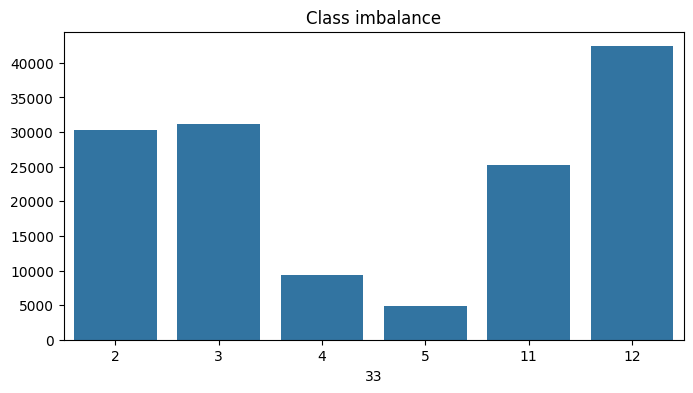

In [57]:
# Class distribution
target_col = df.columns[-1] 
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("--- Class distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_pct[cls]:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class imbalance")
plt.show()


--- Top-5 most variable features ---
        mean       std        cv
32  0.079995  0.123174  1.539770
31  0.096133  0.142950  1.487005
30  0.119489  0.172329  1.442215
18  0.201588  0.290277  1.439953
26  0.126822  0.182542  1.439352


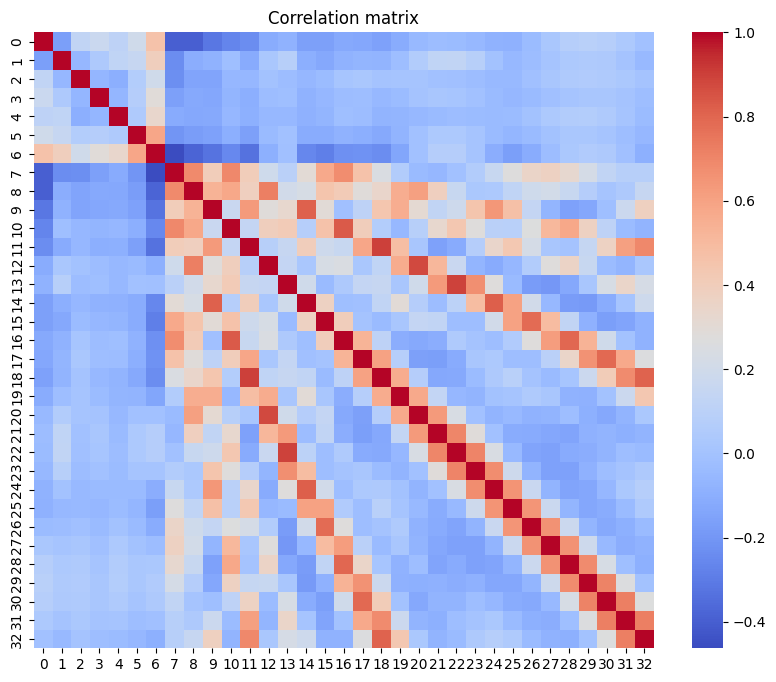

In [ ]:
# Correlation matrix
stats = df.iloc[:, :-1].describe().T
stats['cv'] = stats['std'] / stats['mean'] 
features = stats.sort_values(by='cv', ascending=False).head(5).index.tolist()
print("\n--- Top-5 most variable features ---")
print(stats.sort_values(by='cv', ascending=False)[['mean', 'std', 'cv']].head())

plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :-1].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

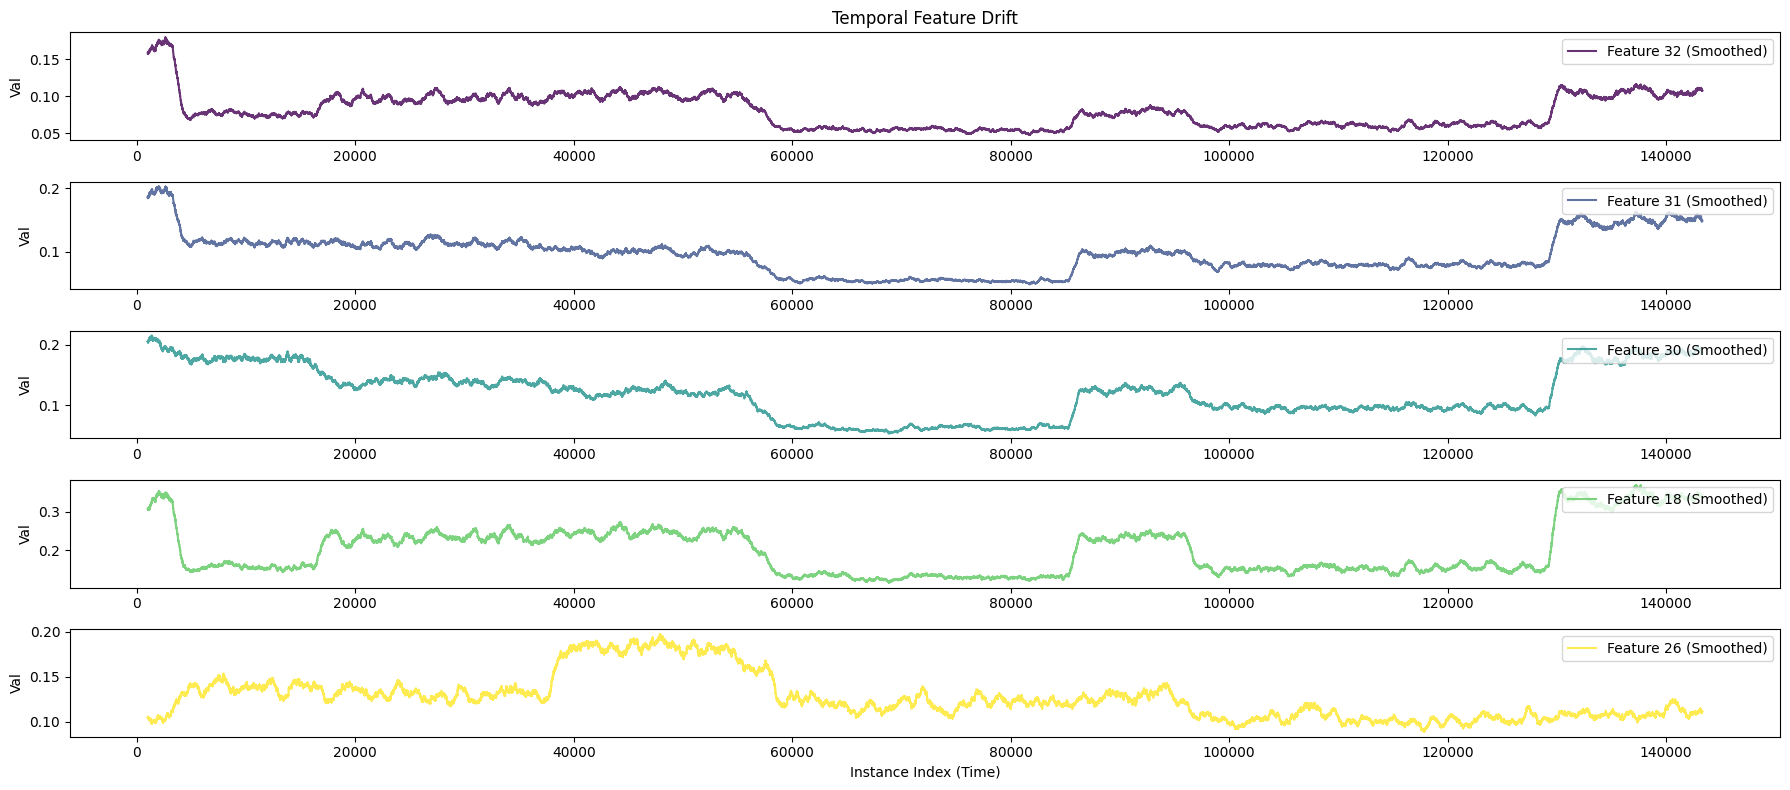

In [ ]:
window_size = 1000

plt.figure(figsize=(18, 8))

for i, col in enumerate(features):

    series = X_df[col].rolling(window=window_size).mean() # Moving average to smooth out noise
    
    plt.subplot(len(features), 1, i+1)
    plt.plot(series, label=f'Feature {col} (Smoothed)', color=plt.cm.viridis(i / 4), alpha=0.8)
    plt.ylabel(f'Val')
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('Temporal Feature Drift')

plt.xlabel('Instance Index (Time)')
plt.tight_layout()
plt.show()

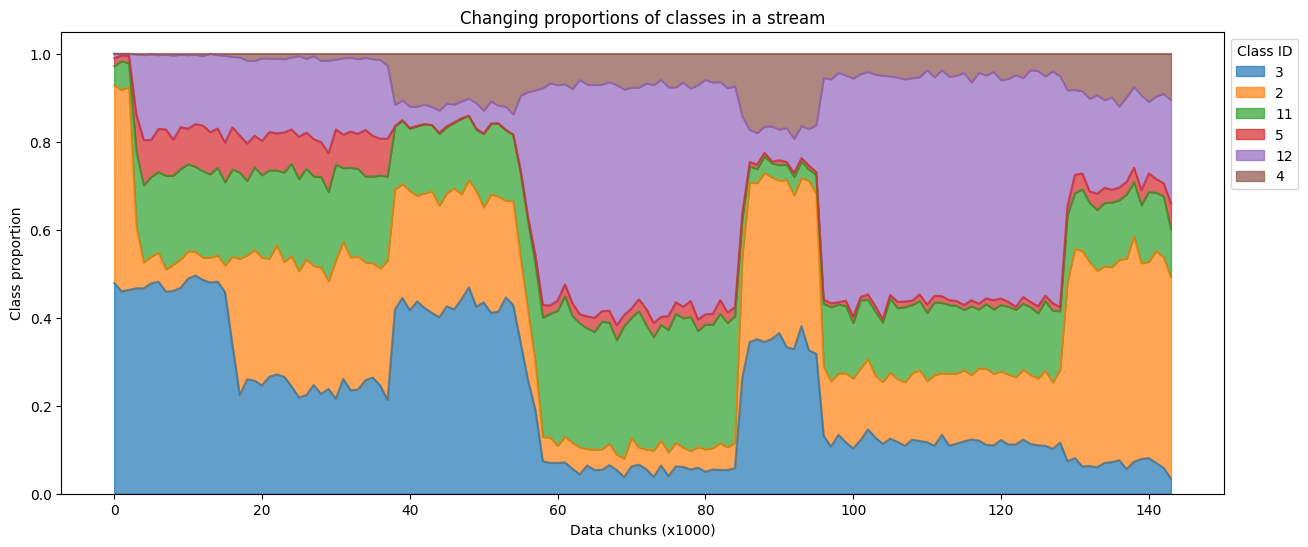

In [61]:
chunks = [df.iloc[i:i + window_size] for i in range(0, len(df), window_size)]

stream_proportions = []
for chunk in chunks:
    counts = chunk[target_col].value_counts(normalize=True).to_dict()
    stream_proportions.append(counts)

prop_df = pd.DataFrame(stream_proportions).fillna(0)

prop_df.plot(kind='area', stacked=True, figsize=(15, 6), alpha=0.7)
plt.title("Changing proportions of classes in a stream")
plt.xlabel(f"Data chunks (x{window_size})")
plt.ylabel("Class proportion")
plt.legend(title="Class ID", bbox_to_anchor=(1, 1))
plt.show()


### Drift Detection

In [ ]:
n_runs = 10
stream_type = "insects_gradual" #rbf, insects_abrupt, insects_gradual
n_features = 33
n_classes = 6

detectors = [
    ("DHAE",lambda: DHAE(n_features=n_features, n_classes=n_classes)),
    ("KSWIN",lambda: PCAKSWIN(n_classes=n_classes)),
    ("DDM", lambda: DDMWrapper()),
    ("ADWIN_Ent", lambda: ADWINEntropy(n_classes=n_classes)),
    ("ADWIN_Err",lambda: ADWINError()),
    ("No_Change",lambda: None)
]

results = {}

for name, detector in detectors:
    print(f"Evaluating detector: {name}")
    results[name] = run_multiple_experiments(
        stream_type=stream_type,
        classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
        detector_factory=detector,
        reset_on_drift=True,
        n_runs=n_runs
    )
    
    print_summary(results[name]["metrics"], name)


In [52]:
for name, res in results.items():
    print_summary(res["metrics"], name)


NoChange
Accuracy            : 0.5634 ± 0.0000
G-Mean              : 0.4482 ± 0.0000
Delay               : 0.0000 ± 0.0000
Recall              : 0.0000 ± 0.0000
Precision           : 0.0000 ± 0.0000
FAR                 : 0.0000 ± 0.0000
HDD                 : 0.0000 ± 0.0000

DDM
Accuracy            : 0.6093 ± 0.0000
G-Mean              : 0.5209 ± 0.0000
Delay               : 27513.0000 ± 0.0000
Recall              : 1.0000 ± 0.0000
Precision           : 0.0385 ± 0.0000
FAR                 : 0.9615 ± 0.0000
HDD                 : 0.0741 ± 0.0000

ADWIN Entropy
Accuracy            : 0.5628 ± 0.0000
G-Mean              : 0.5286 ± 0.0000
Delay               : 4288.0000 ± 0.0000
Recall              : 1.0000 ± 0.0000
Precision           : 0.0204 ± 0.0000
FAR                 : 0.9796 ± 0.0000
HDD                 : 0.0400 ± 0.0000

ADWIN Error
Accuracy            : 0.5718 ± 0.0000
G-Mean              : 0.5385 ± 0.0000
Delay               : 2811.0000 ± 0.0000
Recall              : 1.0000 ± 0.00

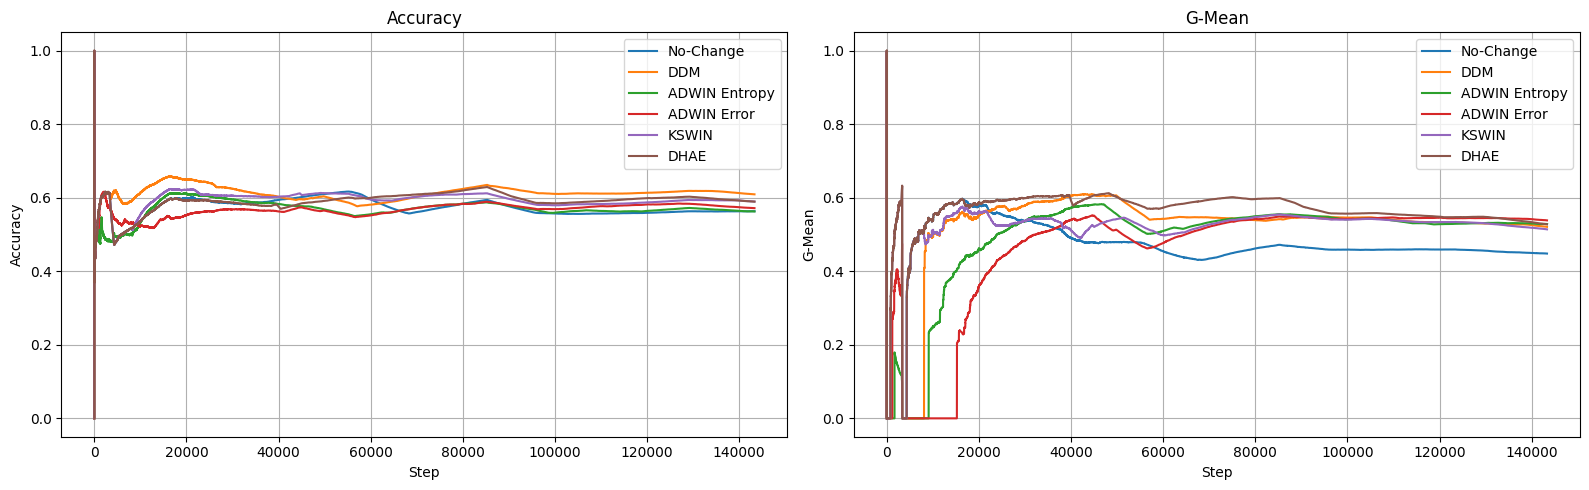

In [53]:
run = 0  

results_for_plot = {
    name: {
        "tracker": data["all_trackers"][run],
        "drifts": data["all_drifts"][run]
    }
    for name, data in results.items()
}

plot_metrics(results_for_plot)

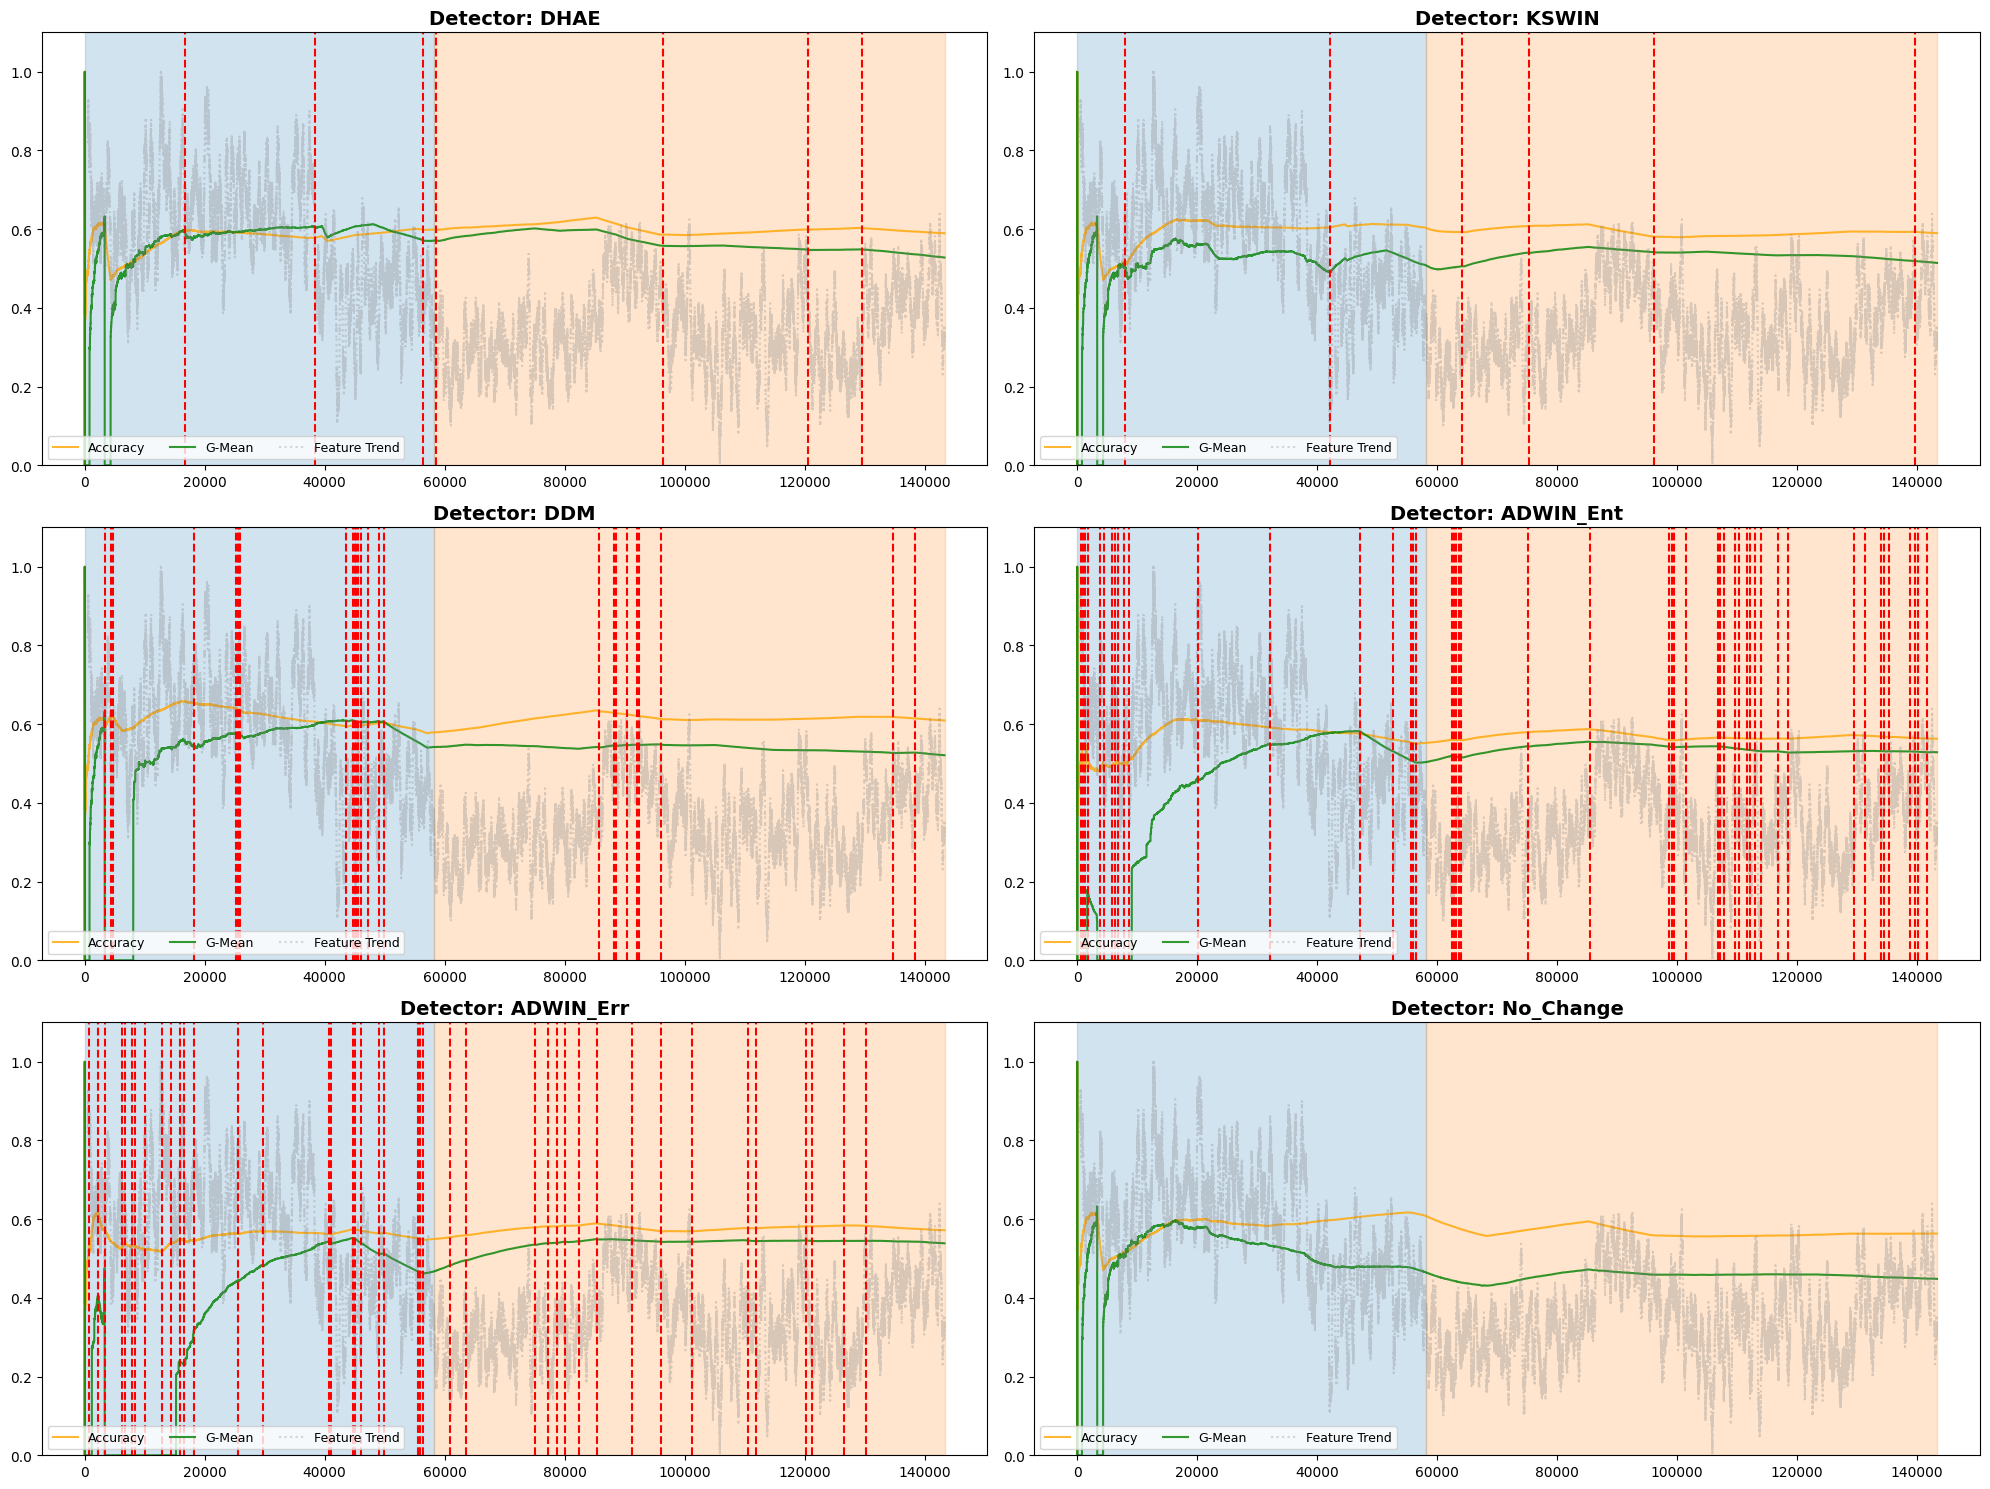

In [86]:
plot_detection_results(results, ground_truth_drifts, X_df=X_df, feature_idx=2)

## Random RBF dataset

### Exploratoin

In [88]:
n_classes= 8
n_features = 30
n_samples= 100000

drift_width=1

#scenario = [{0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1}] # balanced
#scenario = [{0: 0.21, 1: 0.18, 2: 0.15, 3: 0.12, 4: 0.10, 5: 0.09, 6: 0.08, 7: 0.07}] # mild ~ 1:3
scenario = [{0: 0.20, 1: 0.18, 2: 0.16, 3: 0.14, 4: 0.12, 5: 0.10, 6: 0.08, 7: 0.02}] # moderate ~ 1:10
#scenario = [{0: 0.60, 1: 0.12, 2: 0.08, 3: 0.06, 4: 0.05,5: 0.04, 6: 0.03, 7: 0.02}] # severe ~ 1:30

ground_truth_drifts=[20000, 40000, 60000, 80000]

stream = RBFDriftStream(
    n_classes=n_classes, 
    n_features= n_features,
    drift_points=ground_truth_drifts, 
    drift_width=drift_width, 
    imbalance_configs=scenario
)

df = stream_to_df(stream, n_samples)

X_df = df.iloc[:, :-1]
y_series = df.iloc[:,-1] 

print(f"Number of features: {n_features}") 
print(f"Number of samples: {n_samples}")
print(f"Number of classes: {n_classes}")
df.head()


Number of features: 30
Number of samples: 100000
Number of classes: 8


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,label
0,0.057026,0.231862,0.653257,0.227049,0.135709,0.923546,0.579890,0.458337,0.787320,0.796368,...,0.861821,0.261096,0.204446,0.441379,0.429223,0.280573,0.251043,0.936932,0.458188,1
1,0.523234,0.610355,0.879458,0.862410,0.459792,0.518806,0.448908,0.733525,0.391259,0.651050,...,0.731539,0.773305,0.882411,0.043122,0.049076,0.646331,0.918769,1.010589,0.730332,6
2,0.988800,0.982714,0.543877,0.923732,0.565128,0.651219,0.019849,0.420962,0.804777,0.230985,...,0.069154,1.014350,0.295967,0.041283,0.957433,-0.013492,-0.026035,0.235739,0.780386,2
3,0.988845,0.044554,0.831845,0.444394,0.687786,0.375839,0.452414,-0.002124,0.483501,0.489495,...,0.839748,0.697340,0.046040,0.186579,0.310937,0.170618,0.094615,0.738752,0.018894,7
4,0.060042,0.880890,0.425688,0.953881,0.591531,0.596641,0.067490,0.049509,0.690748,0.560330,...,0.652295,0.560004,0.128945,0.533460,0.512478,0.124318,0.336148,0.035300,0.230826,4


--- Class distribution ---
Class 0: 19999 samples (20.00%)
Class 1: 18000 samples (18.00%)
Class 2: 16000 samples (16.00%)
Class 3: 14000 samples (14.00%)
Class 4: 12001 samples (12.00%)
Class 5: 10000 samples (10.00%)
Class 6: 8000 samples (8.00%)
Class 7: 2000 samples (2.00%)


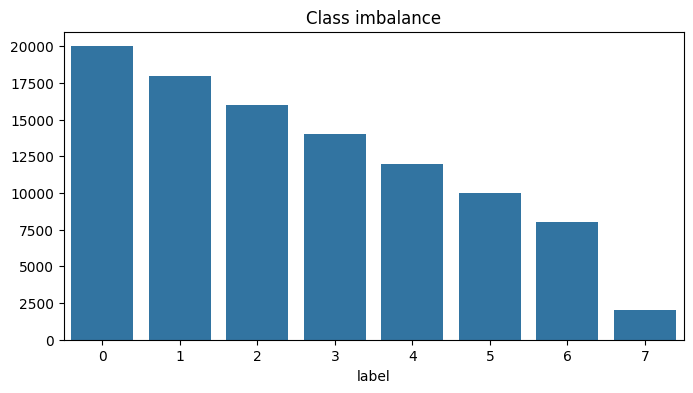

In [89]:
# Class distribution
target_col = df.columns[-1] 
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("--- Class distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_pct[cls]:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class imbalance")
plt.show()

In [ ]:
stats = df.iloc[:, :-2].describe().T
stats['cv'] = stats['std'] / stats['mean'] 
features = stats.sort_values(by='cv', ascending=False).head(5).index.tolist()
print("\n--- Top-5 most variable features ---")
print(stats.sort_values(by='cv', ascending=False)[['mean', 'std', 'cv']].head())


--- Top-5 most variable features ---
        mean       std        cv
19  0.435991  0.322177  0.738953
11  0.467268  0.318938  0.682560
4   0.458419  0.307783  0.671401
8   0.449222  0.301001  0.670049
27  0.466095  0.312033  0.669462


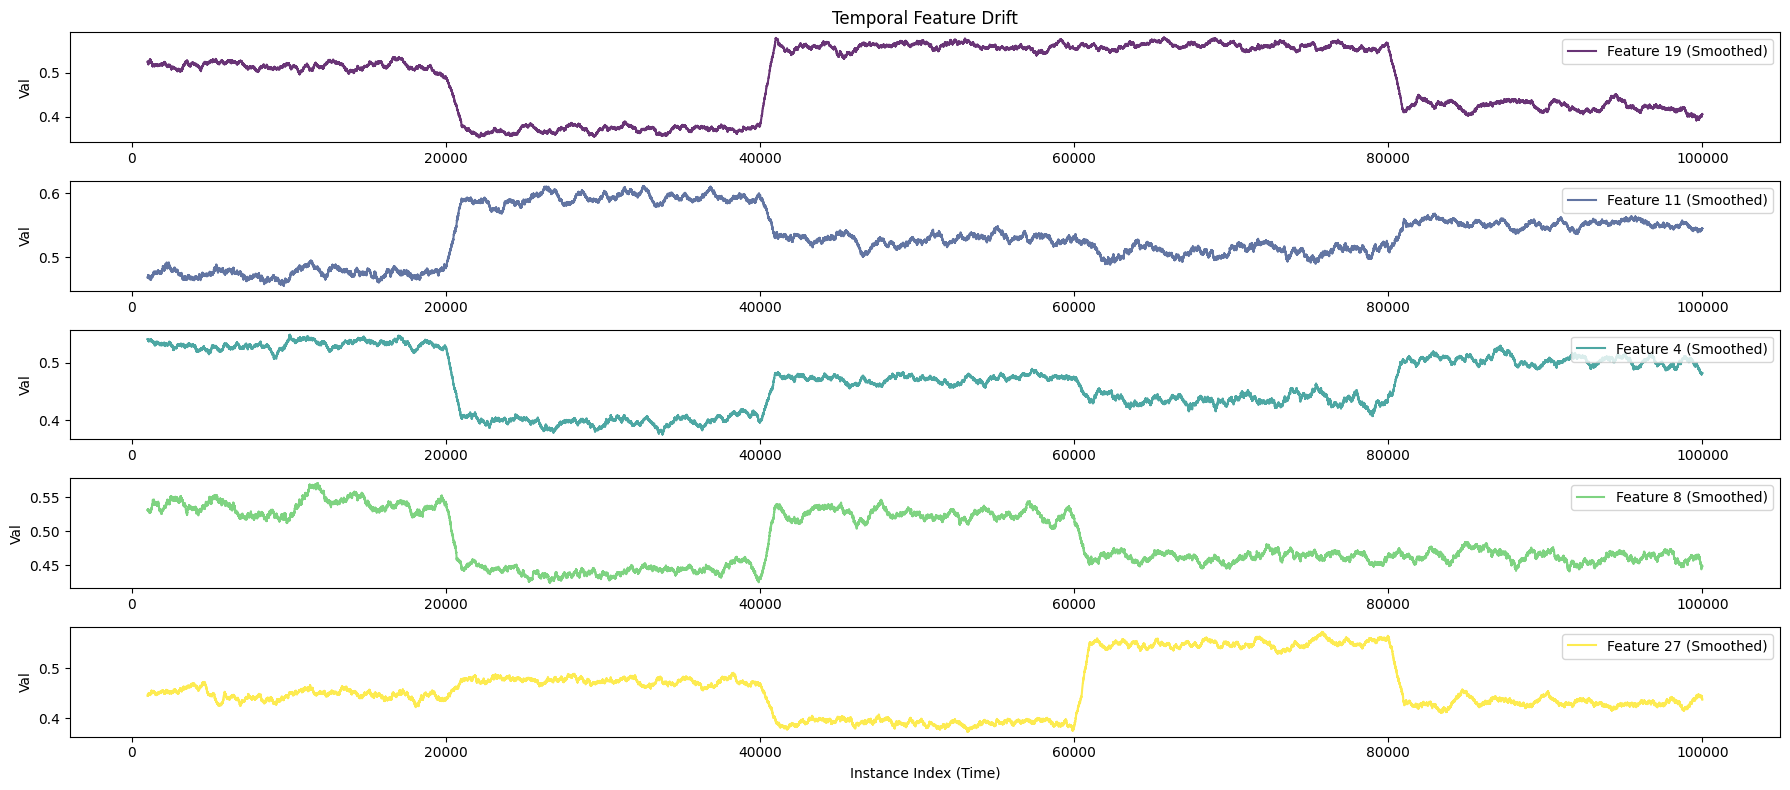

In [91]:
window_size = 1000

plt.figure(figsize=(18, 8))

for i, col in enumerate(features):

    series = X_df.iloc[:, i].rolling(window=window_size).mean()
    
    plt.subplot(len(features), 1, i+1)
    plt.plot(series, label=f'Feature {col} (Smoothed)', color=plt.cm.viridis(i / 4), alpha=0.8)
    plt.ylabel(f'Val')
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('Temporal Feature Drift')

plt.xlabel('Instance Index (Time)')
plt.tight_layout()
plt.show()

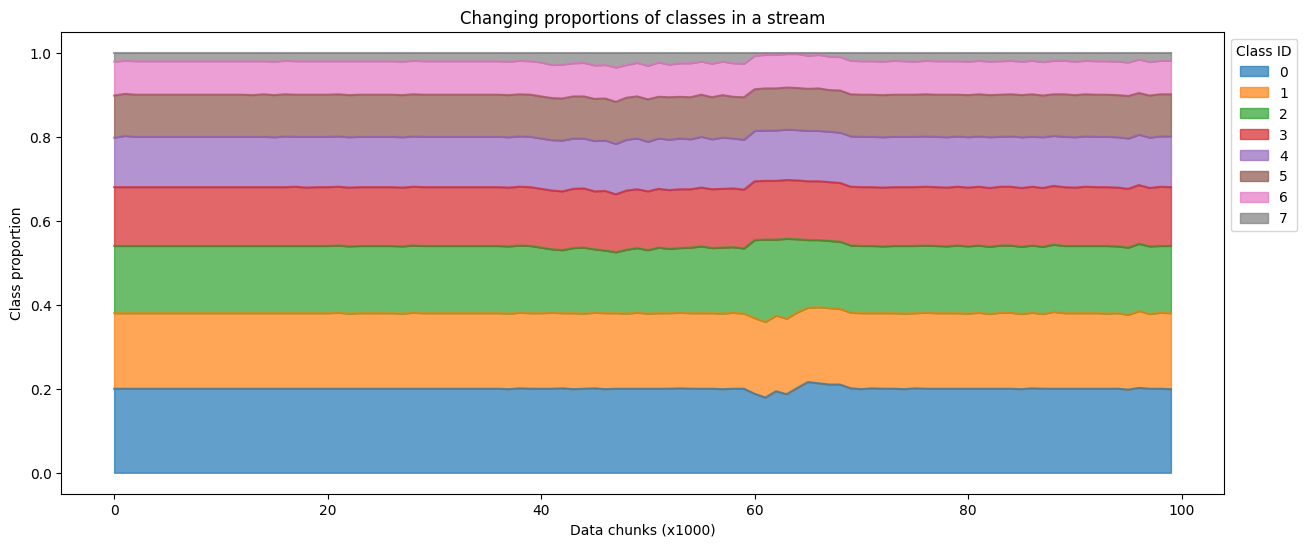

In [93]:
chunks = [df.iloc[i:i + window_size] for i in range(0, len(df), window_size)]

stream_proportions = []
for chunk in chunks:
    counts = chunk[target_col].value_counts(normalize=True).to_dict()
    stream_proportions.append(counts)

prop_df = pd.DataFrame(stream_proportions).fillna(0)

prop_df.plot(kind='area', stacked=True, figsize=(15, 6), alpha=0.7)
plt.title("Changing proportions of classes in a stream")
plt.xlabel(f"Data chunks (x{window_size})")
plt.ylabel("Class proportion")
plt.legend(title="Class ID", bbox_to_anchor=(1, 1))
plt.show()